<a href="https://colab.research.google.com/github/JahnaviRudresh/Cognifyz_Machine_Learning-_Internship/blob/main/cognifyz_task_1_restaurant_rating_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import glob
# Find the uploaded CSV file
files = glob.glob('/content/**/*.csv', recursive=True)

print("CSV files found:")
print(files)

# Load the first CSV file
df = pd.read_csv(files[0])

print("\nDataset loaded successfully!")
print("Shape:", df.shape)

df.head()

CSV files found:
['/content/Dataset  (1).csv', '/content/sample_data/california_housing_train.csv', '/content/sample_data/mnist_train_small.csv', '/content/sample_data/california_housing_test.csv', '/content/sample_data/mnist_test.csv']

Dataset loaded successfully!
Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             955

In [ ]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64
Missing values in each column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering n

In [ ]:
# Fill missing values in the Cuisines column

df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Check again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [ ]:
# Select useful features for predicting restaurant ratings

features = [
    'Average Cost for two',
    'Has Table booking',
    'Has Online delivery',
    'Price range',
    'Votes',
    'City',
    'Cuisines'
]

target = 'Aggregate rating'

X = df[features]
y = df[target]

print("Features selected:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features selected:
['Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Price range', 'Votes', 'City', 'Cuisines']

Target:
Aggregate rating


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Categorical columns
categorical_features = [
    'Has Table booking',
    'Has Online delivery',
    'City',
    'Cuisines'
]

# Create encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Transform the features
X_encoded = preprocessor.fit_transform(X)

print("Encoding completed successfully!")
print("Encoded data shape:", X_encoded.shape)

Encoding completed successfully!
Encoded data shape: (9551, 1974)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7640, 1974)
Testing data: (1911, 1974)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully! 🤖")

Model trained successfully! 🤖


In [ ]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions completed successfully! 🎯")
print("First 10 predicted ratings:")
print(y_pred[:10])

Predictions completed successfully! 🎯
First 10 predicted ratings:
[1.29135756 3.287399   1.88640637 2.761572   1.92258121 2.06954578
 2.90709579 2.11084029 2.44284529 3.28636509]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
Mean Squared Error (MSE): 1.4618444163508033
R² Score: 0.35774410514848165


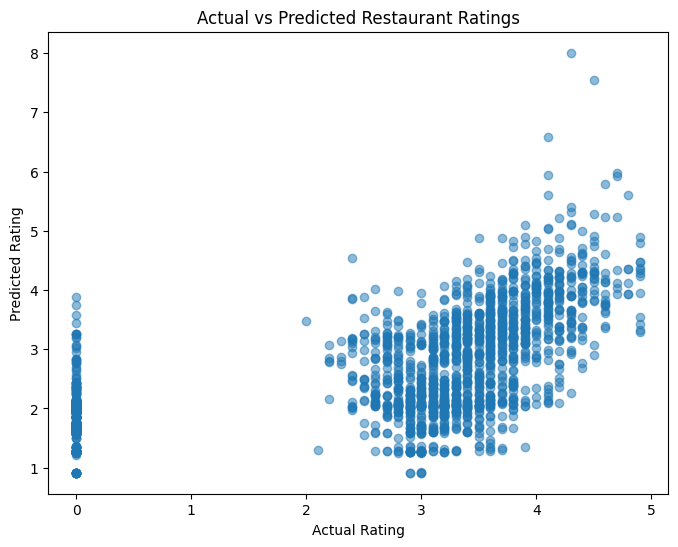

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")

plt.show()

In [ ]:
# Check correlation between numerical features and restaurant rating

numerical_features = [
    'Average Cost for two',
    'Price range',
    'Votes',
    'Aggregate rating'
]

correlation = df[numerical_features].corr()

print("Correlation with Aggregate Rating:")
print(correlation['Aggregate rating'].sort_values(ascending=False))

Correlation with Aggregate Rating:
Aggregate rating        1.000000
Price range             0.437944
Votes                   0.313691
Average Cost for two    0.051792
Name: Aggregate rating, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully! 🌳🤖")

Random Forest model trained successfully! 🌳🤖


In [ ]:
# Make predictions using Random Forest

rf_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Evaluation Results")
print("--------------------------------")
print("Mean Squared Error (MSE):", rf_mse)
print("R² Score:", rf_r2)

Random Forest Evaluation Results
--------------------------------
Mean Squared Error (MSE): 0.10215705485626972
R² Score: 0.9551176787705674


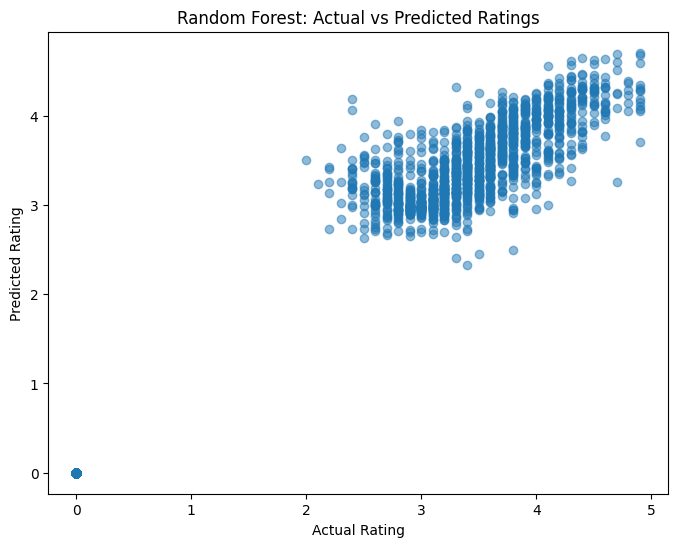

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Random Forest: Actual vs Predicted Ratings")

plt.show()

In [ ]:
# Feature importance from Random Forest

import pandas as pd

feature_names = preprocessor.get_feature_names_out()

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                                           Feature  Importance
1973                              remainder__Votes    0.950083
1971               remainder__Average Cost for two    0.008905
1972                        remainder__Price range    0.003064
92                             cat__City_New Delhi    0.002355
93                                 cat__City_Noida    0.001714
54                               cat__City_Gurgaon    0.001090
2                      cat__Has Online delivery_No    0.000998
1474           cat__Cuisines_North Indian, Chinese    0.000988
3                     cat__Has Online delivery_Yes    0.000939
115                       cat__City_Rio de Janeiro    0.000905
1665  cat__Cuisines_North Indian, Mughlai, Chinese    0.000787
1659           cat__Cuisines_North Indian, Mughlai    0.000746
1451                    cat__Cuisines_North Indian    0.000743
1771                cat__Cuisines_Pizza, Fast Food    0.000699
642                         

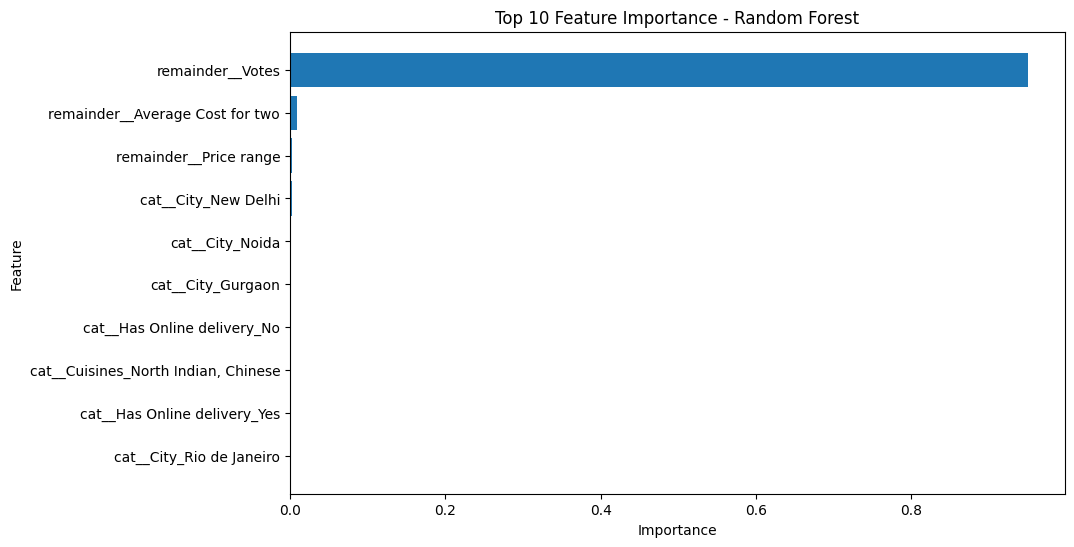

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.gca().invert_yaxis()
plt.show()